# Project Catalyst — Diagnostic EDA
### Commercial Growth Diagnostic & Sales-Force Effectiveness

This notebook walks the diagnostic story interactively. It calls the same functions as `scripts/run_eda.py`, so the notebook and the committed `reports/eda_report.md` never drift.

> **The question:** the client spends more to grow less. *Where* is the growth hiding, and *why* is effort not converting? We recover six commercial truths (P1–P6) from raw data.

In [1]:
import os, sys
from pathlib import Path
root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
os.chdir(root); sys.path.insert(0, 'src')
from IPython.display import Image, display
from catalyst.analytics import eda
from catalyst.data_pipeline.validate import load_tables
from catalyst.utils.config import load_config
from catalyst.visualization import theme as T
T.apply_theme()
cfg = load_config()
t = load_tables()
ctx = eda.build_context(t)
summary = eda.doctor_summary(t, ctx)
def show(res):
    display(Image('reports/' + res['path']))
print('Doctors:', len(t['dim_doctor']), '| Prescriptions:', len(t['fact_prescriptions']))

Doctors: 18000 | Prescriptions: 2771136


## 1. The symptom: flat revenue
Revenue is essentially flat despite rising spend — a resource-allocation problem, not a demand problem.

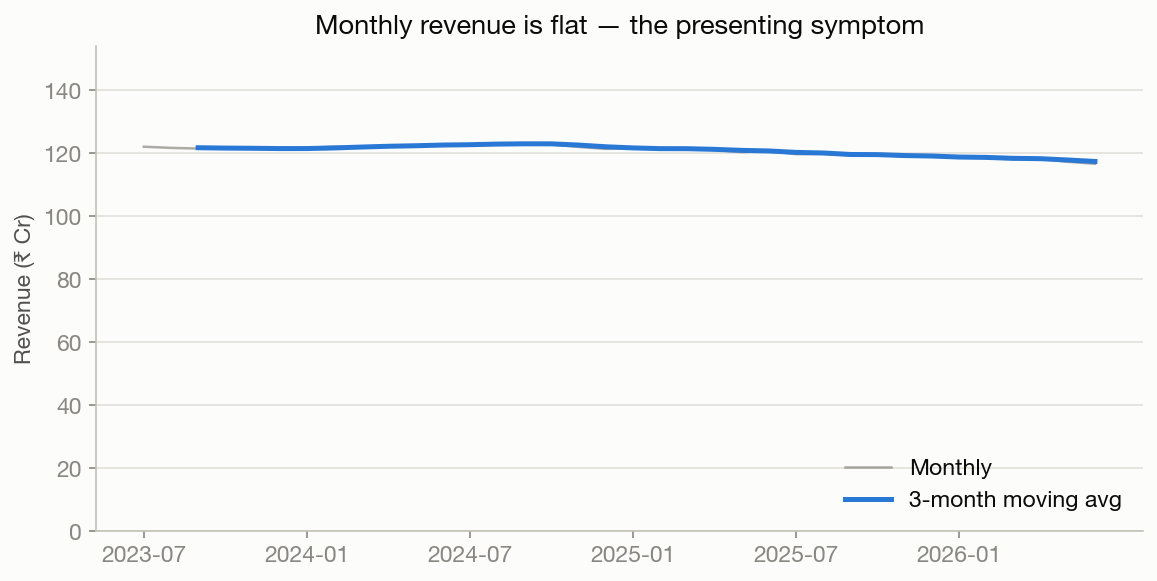

Annual revenue: Rs 1,424 Cr | YoY growth: -2.6%


In [2]:
r = eda.chart_revenue_trend(t, ctx); show(r)
print(f"Annual revenue: Rs {r['annual']:,.0f} Cr | YoY growth: {r['yoy']:+.1f}%")

## 2. The paradox: stagnation hides divergence (P4)
The flat total is an *average of opposites* — declining mature brands mask a healthy growth portfolio.

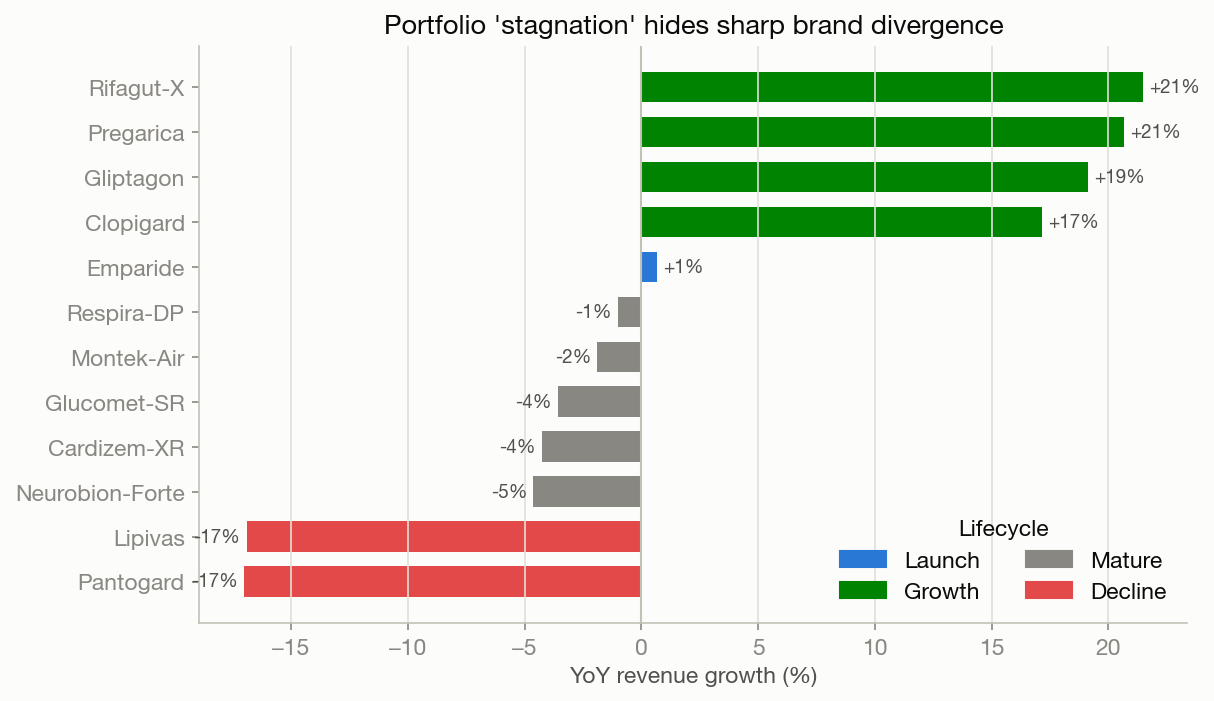

Worst: Pantogard -17% | Best: Rifagut-X +21%


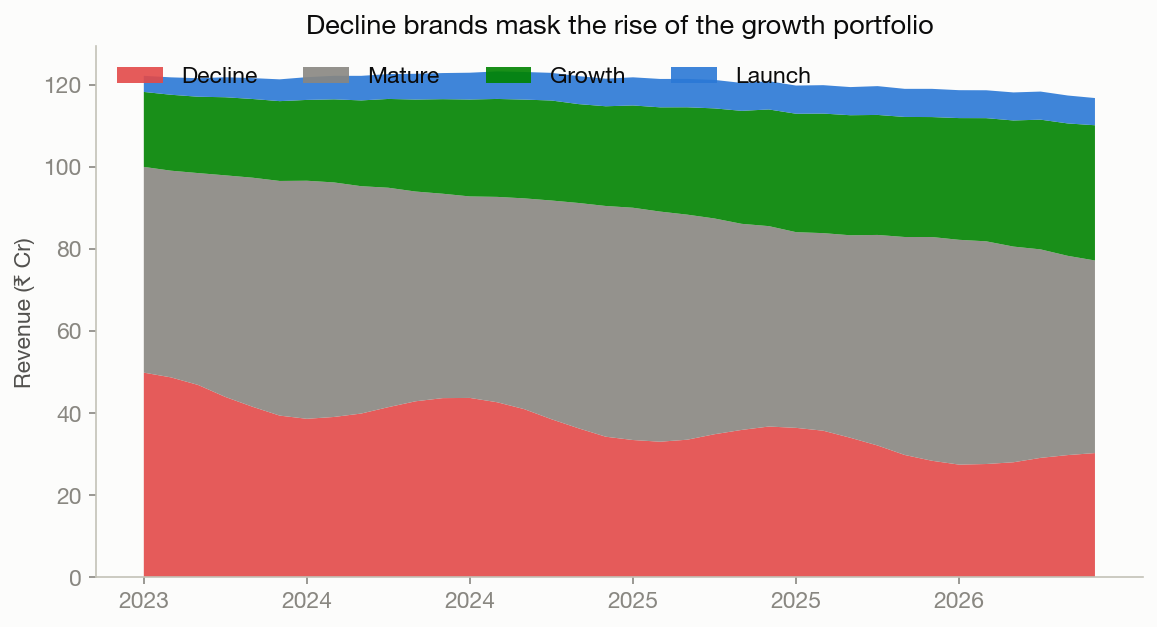

In [3]:
b = eda.chart_brand_growth(t, ctx); show(b)
print(f"Worst: {b['worst']} {b['worst_val']:+.0f}% | Best: {b['best']} {b['best_val']:+.0f}%")
show(eda.chart_lifecycle_area(t, ctx))

## 3. Customers are concentrated
A minority of prescribers drives most revenue — targeting must be differentiated.

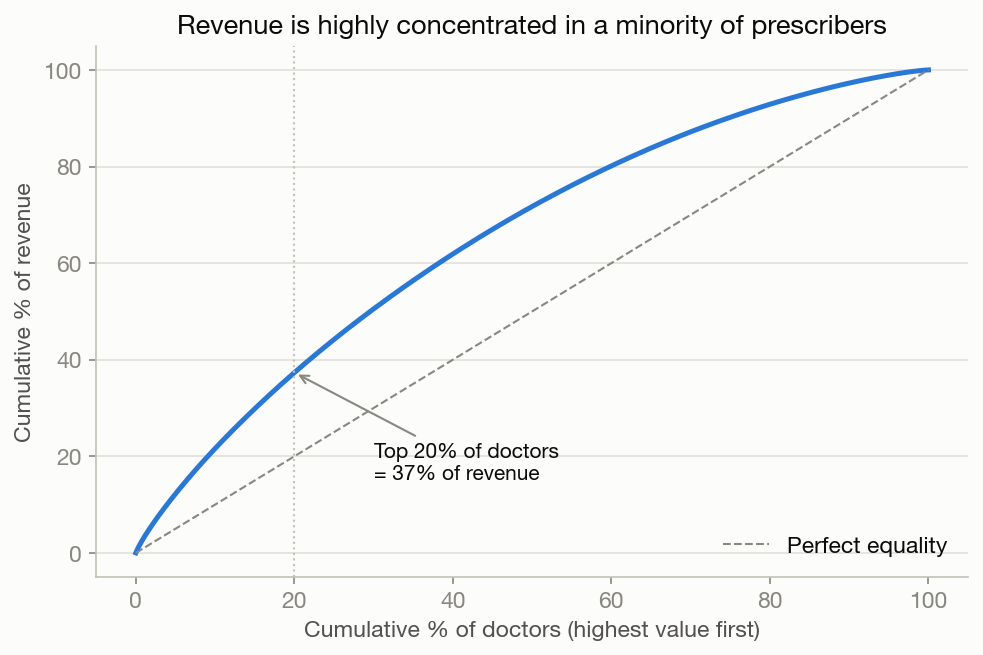

Top 20% of doctors = 37% of revenue


In [4]:
cc = eda.chart_decile_concentration(summary); show(cc)
print(f"Top 20% of doctors = {cc['top20']:.0f}% of revenue")

## 4. The smoking gun: effort chases volume, not potential (P1)
Sales calls track *current* prescribing far more than *potential*. The shaded quadrant is the **white space** — high-potential, under-called doctors.

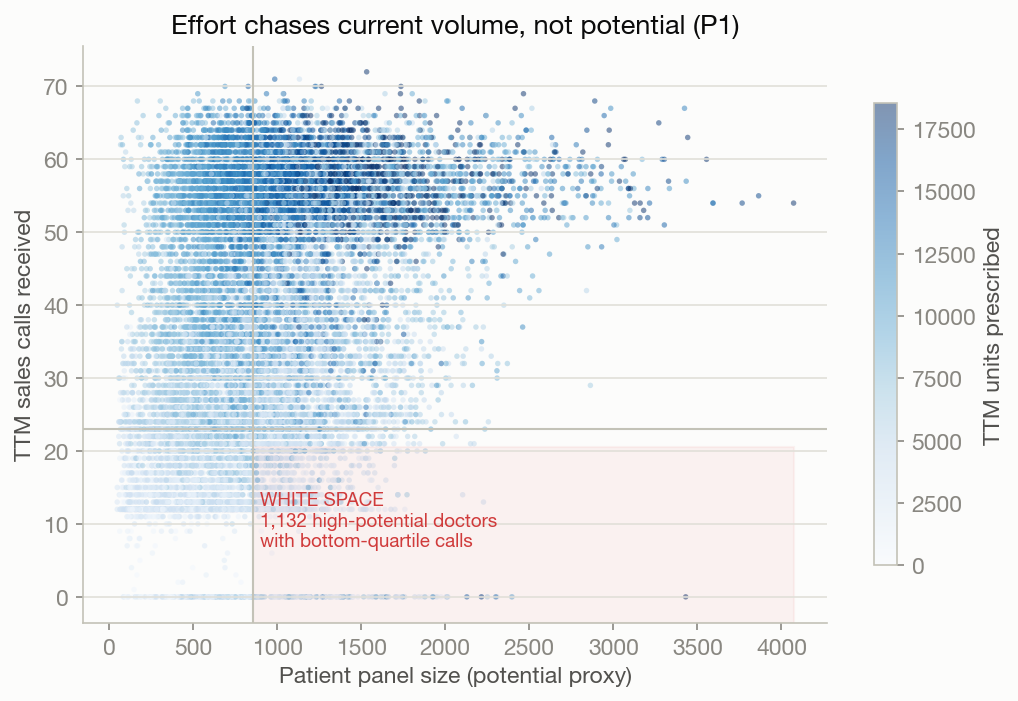

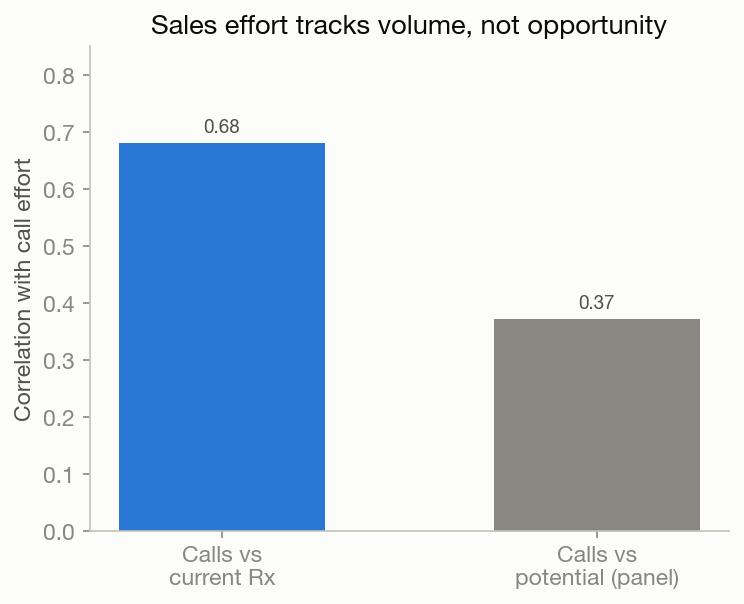

corr(calls, current Rx)=0.68 vs corr(calls, potential)=0.37
White space: 1,132 high-potential doctors under-called


In [5]:
g = eda.chart_effort_gap(summary); show(g)
cr = eda.chart_effort_corr(summary); show(cr)
print(f"corr(calls, current Rx)={cr['c_rx']:.2f} vs corr(calls, potential)={cr['c_pan']:.2f}")
print(f"White space: {g['whitespace_docs']:,} high-potential doctors under-called")

## 5. Over-called doctors are saturating (P2)
Diminishing returns: each additional call on already-loyal doctors yields less.

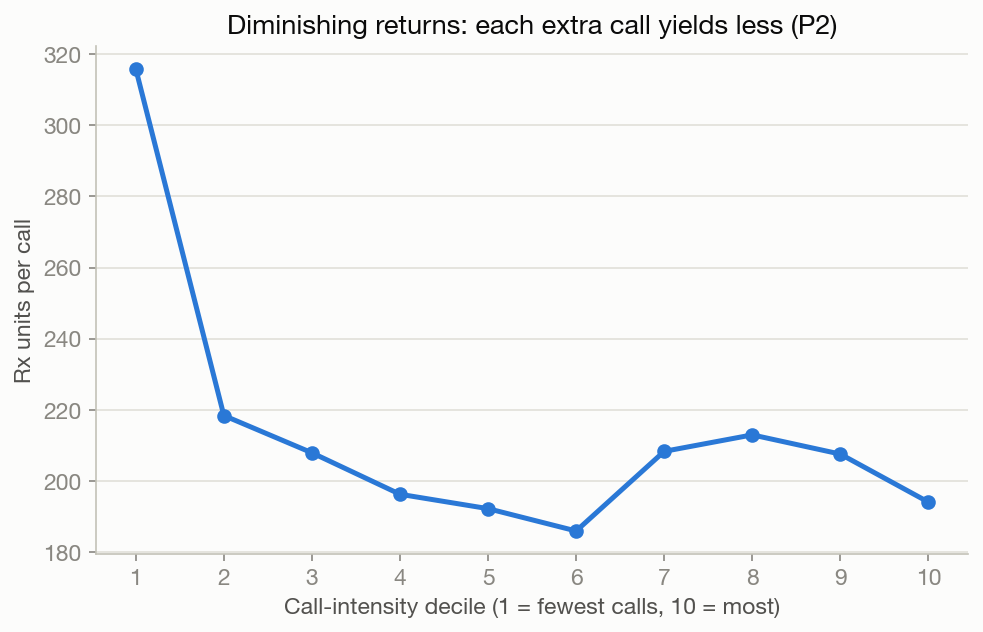

Rx/call: 247 (low intensity) -> 205 (high intensity)


In [6]:
d = eda.chart_diminishing_returns(summary); show(d)
print(f"Rx/call: {d['low']:.0f} (low intensity) -> {d['high']:.0f} (high intensity)")

## 6. Under-resourced territories (P3)
Some territories combine high potential with low coverage — re-alignment targets.

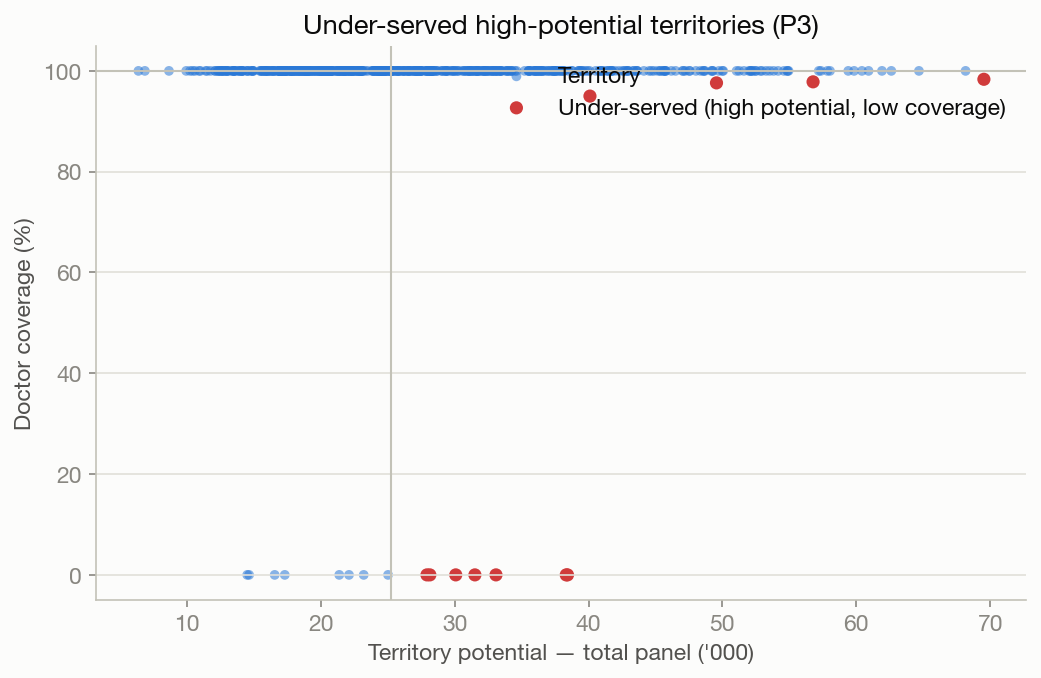

11 under-served territories (avg coverage 35%)


In [7]:
cv = eda.chart_territory_coverage(t, ctx, summary); show(cv)
print(f"{cv['n_under']} under-served territories (avg coverage {cv['avg_cov']:.0f}%)")

## 7. Marketing money in the wrong channel (P5)
The largest budget sits in the lowest-ROI channel — a near-free lever.

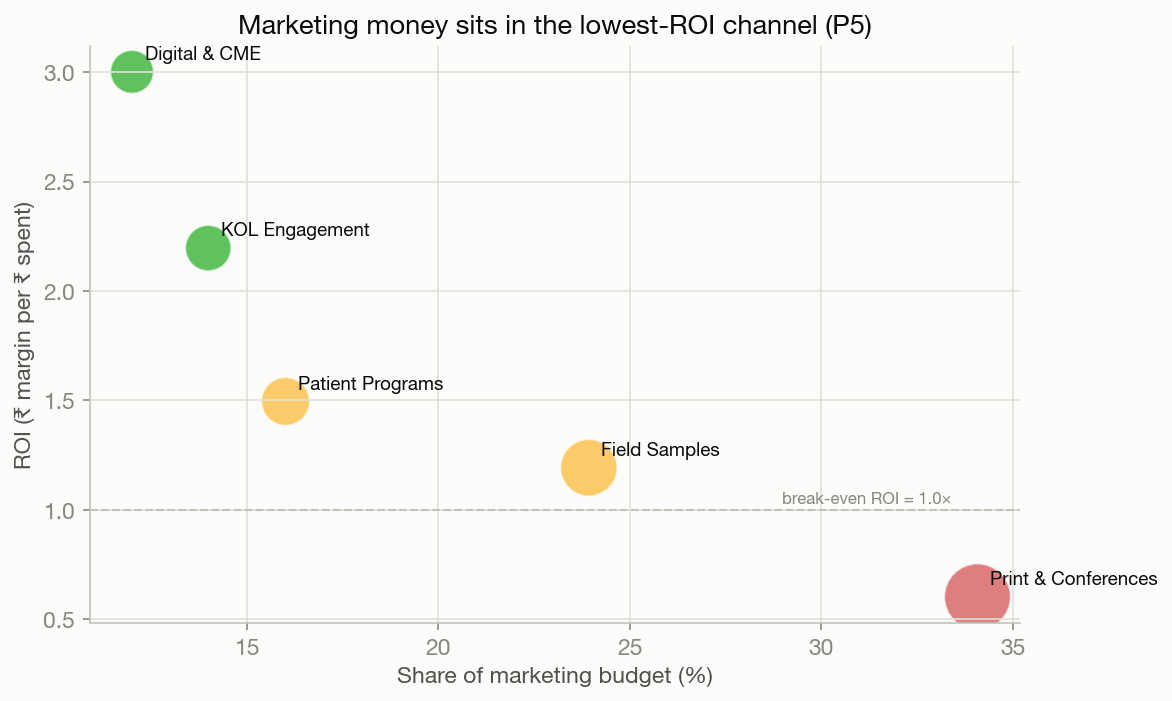

Print & Conferences: 0.60x ROI @ 34% budget
Digital & CME: 3.00x ROI @ 12% budget


In [8]:
m = eda.chart_marketing_roi(t); show(m)
print(f"Print & Conferences: {m['print_roi']:.2f}x ROI @ {m['print_share']:.0f}% budget")
print(f"Digital & CME: {m['digi_roi']:.2f}x ROI @ {m['digi_share']:.0f}% budget")

## 8. Competitive loss is localised (P6)
Share erodes only in specific zones/TAs — the fix should be targeted, not blanket.

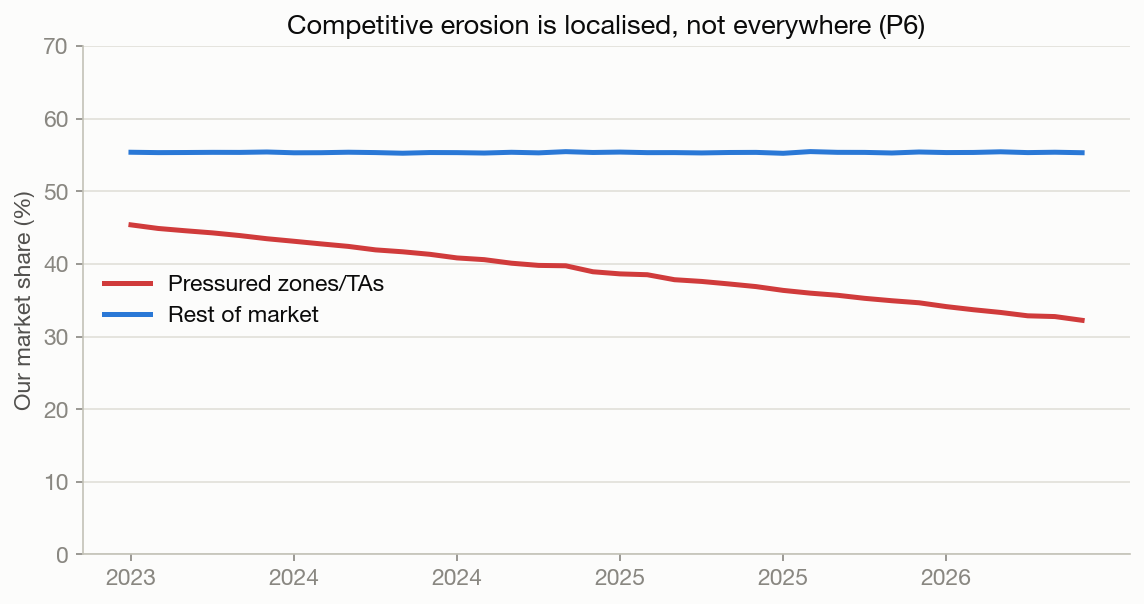

Pressured share: 44% -> 33% | Rest: 55% -> 55%


In [9]:
s = eda.chart_share_trend(t, ctx); show(s)
print(f"Pressured share: {s['p_first']:.0f}% -> {s['p_last']:.0f}% | Rest: {s['r_first']:.0f}% -> {s['r_last']:.0f}%")

## So what — the diagnostic thesis
1. **Reallocate field effort** from saturated high-deciles to the white space and under-served territories.
2. **Re-weight marketing** from Print toward Digital/CME.
3. **Rebalance promotion** toward growth brands; manage the declining hero for cash.
4. **Defend selectively** in pressured zones.

Milestones 4–8 quantify each in rupees: segmentation → opportunity scoring → optimization → financial model.